## From Tapology to Topology: Mapping MMA’s Fighter Network

How data scraped from Tapology — one of the largest online MMA databases — can be used to build and visualize a fighter network graph. By turning fight records into network data, we can explore patterns that reveal unexpected connections, influential fighters, and the structure of the MMA world as a living, breathing ecosystem.

In [2]:
import requests
from bs4 import BeautifulSoup

tapology = requests.get('https://www.tapology.com/')
soup = BeautifulSoup(tapology.content, 'html.parser')

print(soup.title.string)

Tapology | MMA & Combat Sports


### Round 1 — The Press Conference: Introducing the Dataset

**Tapology** (*“Tap” — the act of submitting, surrender + “-ology” — from the Greek -λογία (-logia), “the study of"*) is one of the largest online repositories of fighter profiles, fight histories, and event details on the web, and it has become an unofficial encyclopedia of the MMA world. In this project, we model Tapology’s data as a graph where each node corresponds to a fighter, and each edge represents a recorded fight between two fighters. This allows us to construct a network graph capturing the complex interactions within MMA, enabling quantitative analysis of connectivity, centrality, and community structure in the fighter ecosystem.

To build our fighter network, the first step is to scrape data directly from Tapology’s publicly available fight records. Using Python tools like requests and BeautifulSoup, we programmatically navigate fighter profiles to extract key information such as fighter names, fight dates and outcomes. Once collected, the raw data undergoes cleaning and normalization to standardize fighter names and remove duplicate or irrelevant entries. This preparation ensures that when we construct the network graph, the nodes and edges accurately represent meaningful relationships between fighters across different events and weight divisions.

To scrape Tapology without getting blocked, it’s important to rotate User-Agent headers to mimic different browsers.

In [3]:
import httpx
from fake_useragent import UserAgent
from tenacity import retry, stop_after_attempt, wait_exponential

ua = UserAgent()


@retry(stop=stop_after_attempt(10), wait=wait_exponential(multiplier=10, min=20, max=100))
def fetch_page(path: str):
    headers = {"User-Agent": ua.random}
    url = "https://www.tapology.com" + path
    with httpx.Client(headers=headers) as client:
        response = client.get(url)
        response.raise_for_status()
        return BeautifulSoup(response.text, "html.parser")
    
do_bronx = fetch_page("/fightcenter/fighters/charles-oliveira-do-bronx")
print(do_bronx.title.string)

Charles Oliveira ("do Bronxs") | MMA Fighter Page | Tapology


To extract meaningful fight data from each fighter’s page, we scrape key information including the fighter’s name, their professional bouts, and details about each fight. For every bout, we capture the opponent’s name and ID, the fight outcome (win/loss), the method of victory or defeat (e.g., KO, submission), and the event where the fight took place. This structured extraction provides the raw material to build edges between fighters and enrich our network with contextual metadata, forming a solid foundation for later analysis.

In [4]:
import re

def scrape_fighter_page(fighter_id):
    soup = fetch_page("/fightcenter/fighters/" + fighter_id)
    bouts = soup.find("div", id="proResults")
    if not bouts:
        print(f"No professional bouts found for fighter ID {fighter_id}")
        return None

    fighter_name = soup.select_one(
        "#fighterPageHeader > div:nth-of-type(2) > div:nth-of-type(1) > div:nth-of-type(2)"
    ).text.strip()

    results = []
    professional_bouts = bouts.find_all("div", {"data-division": "pro"})
    for bout in professional_bouts:
        # The first div contains bout information
        bout_info = bout.find("div")
        sections = bout_info.find_all("div", recursive=False)

        # The second section contains the win/loss method
        method_div = sections[1].find("div")
        if not method_div:
            # Skip cancelled or upcoming bouts
            continue
        method = method_div.get_text(strip=True)
        # The first section contains Win/Loss
        decision = sections[0].get_text(strip=True)

        # The third section contains opponent information
        opponent = sections[2].find("a")
        if not opponent:
            # Skip bouts without an opponent
            continue

        opponent_name = opponent.get_text(strip=True)
        opponent_fighter_id = opponent["href"].split("/")[-1]
        # It also contains event information
        banner = sections[2].find("img")
        event = banner.get("alt", "Unknown Event") if banner else "Unknown Event"


        # Find the div with id starting with "detail-rows-"
        detail_rows_div = bout.find("div", id=re.compile(r"^detail-rows-\d+$"))
        
        # Example: "Lightweight · 155 lbs (70.3 kg)"
        weight_class_text = detail_rows_div.get_text(" ", strip=True)
        match = re.search(r"Weight:\s*([^\s·]+)", weight_class_text)
        if match:
            weight_class = match.group(1)
        else:
            weight_class = "Unknown"

        results.append(
            {
                "fighter_name": fighter_name,
                "opponent_name": opponent_name,
                "decision": decision,
                "method": method,
                "event": event,
                "weight_class": weight_class,
                "fighter_id": fighter_id,
                "opponent_fighter_id": opponent_fighter_id,
            }
        )

    return results


bouts = scrape_fighter_page("charles-oliveira-do-bronx")
print(next(iter(bouts)))

{'fighter_name': 'Charles Oliveira', 'opponent_name': 'Ilia Topuria', 'decision': 'L', 'method': 'TKO', 'event': 'UFC', 'weight_class': 'Lightweight', 'fighter_id': 'charles-oliveira-do-bronx', 'opponent_fighter_id': '129278-ilia-topuria'}


To map the interconnected landscape of MMA fighters, we use a **depth-limited Depth-First Search (DFS)** approach to recursively scrape fight data starting from a single fighter. Beginning with a chosen fighter ID, we extract their fight history and then explore their opponents’ profiles, continuing this process up to a specified recursion depth.

This method ensures that we progressively build a network of fighters connected through bouts, while the depth limit and a visited set prevent infinite loops and excessive requests. By applying this controlled traversal, we efficiently capture a meaningful subgraph of the overall MMA fight network, setting the stage for comprehensive network analysis.

In [5]:
def scrape_fighter_network(fighter_id, depth=1, visited=None):
    if visited is None:
        visited = set()
    if depth == 0 or fighter_id in visited:
        return []

    visited.add(fighter_id)
    bouts = scrape_fighter_page(fighter_id)
    if not bouts:
        return []

    network = []
    for bout in bouts:
        opponent_id = bout["opponent_fighter_id"]
        network.append(bout)
        network.extend(scrape_fighter_network(opponent_id, depth - 1, visited))

    return network

charles_bouts = scrape_fighter_network("charles-oliveira-do-bronx", depth=1)
print(f"Charles Oliveira has {len(charles_bouts)} bouts in his MMA career.")

Charles Oliveira has 48 bouts in his MMA career.


Due to time and resource constraints, the recursive scraping depth was limited to 2 levels. This means starting from the chosen fighter, we explore up to two layers of connected opponents in the fight network. For this analysis, I selected Charles Oliveira (“Do Bronx”) as the starting point—not only because he is a top-tier fighter but also my personal favorite. This approach allows us to capture a rich, yet manageable, portion of the MMA network centered around a prominent and active athlete.

In [7]:
network = scrape_fighter_network("charles-oliveira-do-bronx", depth=2)
print(f"Network size: {len(network)} bouts involving Charles Oliveira and his opponents.")

Network size: 1421 bouts involving Charles Oliveira and his opponents.


To keep the network focused and consistent, I chose to include only UFC bouts. While Tapology tracks fights from various organizations and combat sports, filtering for UFC events ensures that all bouts share similar competitive standards and data quality, making the resulting graph more coherent and easier to interpret.

Additionally, only fights with a clear win or loss result were included. Draws and no contests were excluded to ensure that every edge in the network represents a decisive outcome, which simplifies the analysis of connections and rivalries within the graph.

In [8]:
import networkx as nx
import pandas as pd
from collections import Counter


def filter_ufc_fights(df):
    """
    Filter the DataFrame to include only UFC bouts with clear win/loss results.
    """
    return df[(df["event"] == "UFC") & (df["decision"].isin(["W", "L"]))]


def graph_from_dataframe(df):
    """
    Build a network graph from fighter bout data.
    Creates directed edges from winner to loser.
    """
    graph = nx.DiGraph()
    for _, row in df.iterrows():
        fighter = row["fighter_name"]
        opponent = row["opponent_name"]
        decision = row["decision"]

        # Determine winner and loser based on decision
        if decision == "W":
            # Fighter won, so edge goes from fighter to opponent
            winner, loser = fighter, opponent
        elif decision == "L":
            # Fighter lost, so edge goes from opponent to fighter
            winner, loser = opponent, fighter
        else:
            # For draws or unclear decisions, skip or handle differently
            # You could add undirected edge or skip entirely
            continue

        # Add directed edge from winner to loser
        graph.add_edge(winner, loser, event=row["event"], decision=decision, method=row["method"])

    return graph


def assign_weight_class(graph, df):
    # For each node, find all bouts where the fighter is either fighter_name or opponent_name
    for node in graph.nodes:
        bouts = df[(df["fighter_name"] == node) | (df["opponent_name"] == node)]
        if not bouts.empty:
            # Get the most common weight_class
            weight_classes = bouts["weight_class"]
            most_common = Counter(weight_classes).most_common(1)
            if most_common:
                graph.nodes[node]["weight_class"] = most_common[0][0]
            else:
                graph.nodes[node]["weight_class"] = "Unknown"
        else:
            graph.nodes[node]["weight_class"] = "Unknown"


fighter_df = pd.DataFrame(network)
filtered_fights = filter_ufc_fights(fighter_df)
fighter_graph = graph_from_dataframe(filtered_fights)
assign_weight_class(fighter_graph, fighter_df)
print(f"Graph has {fighter_graph.number_of_nodes()} nodes and {fighter_graph.number_of_edges()} edges.")

Graph has 277 nodes and 513 edges.


In the resulting graph, each node represents a fighter, and each edge represents a single bout directed from the winner to the loser. This directionality allows us to analyze not just connections, but also the flow of victories and defeats through the network, revealing patterns of dominance and rivalry.

Here's a peek at the structure of the graph, grouped by weight class:

In [59]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

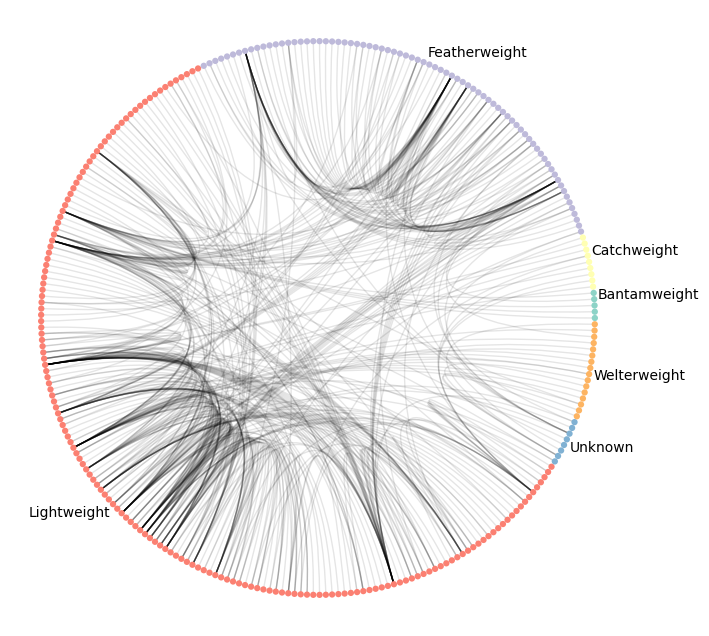

In [60]:
import nxviz as nv
import matplotlib.pyplot as plt
from nxviz import annotate

plt.figure(figsize=(16, 8))

ax = nv.circos(fighter_graph, node_color_by="weight_class", sort_by="weight_class")
annotate.circos_group(fighter_graph, group_by="weight_class")

### Round 2 — The Weigh-In: Exploring the Network

With our fight data scraped and the network graph already constructed, it’s time to weigh in and see what kind of structure we’re dealing with. In this round, we’ll take a closer look at the adjacency matrix, which reveals every win–loss relationship in the network.

We’ll also check some key statistics: the total number of fighters (nodes), the number of bouts (edges), and the network’s density and sparsity — all of which tell us how tightly this part of the MMA world is connected. Finally, we’ll visualize the degree distribution, giving us insight into how active each fighter is in terms of wins and losses.

By the end of this round, we’ll have a solid read on the basic shape of the network — ready to move on to more advanced metrics and deeper patterns.

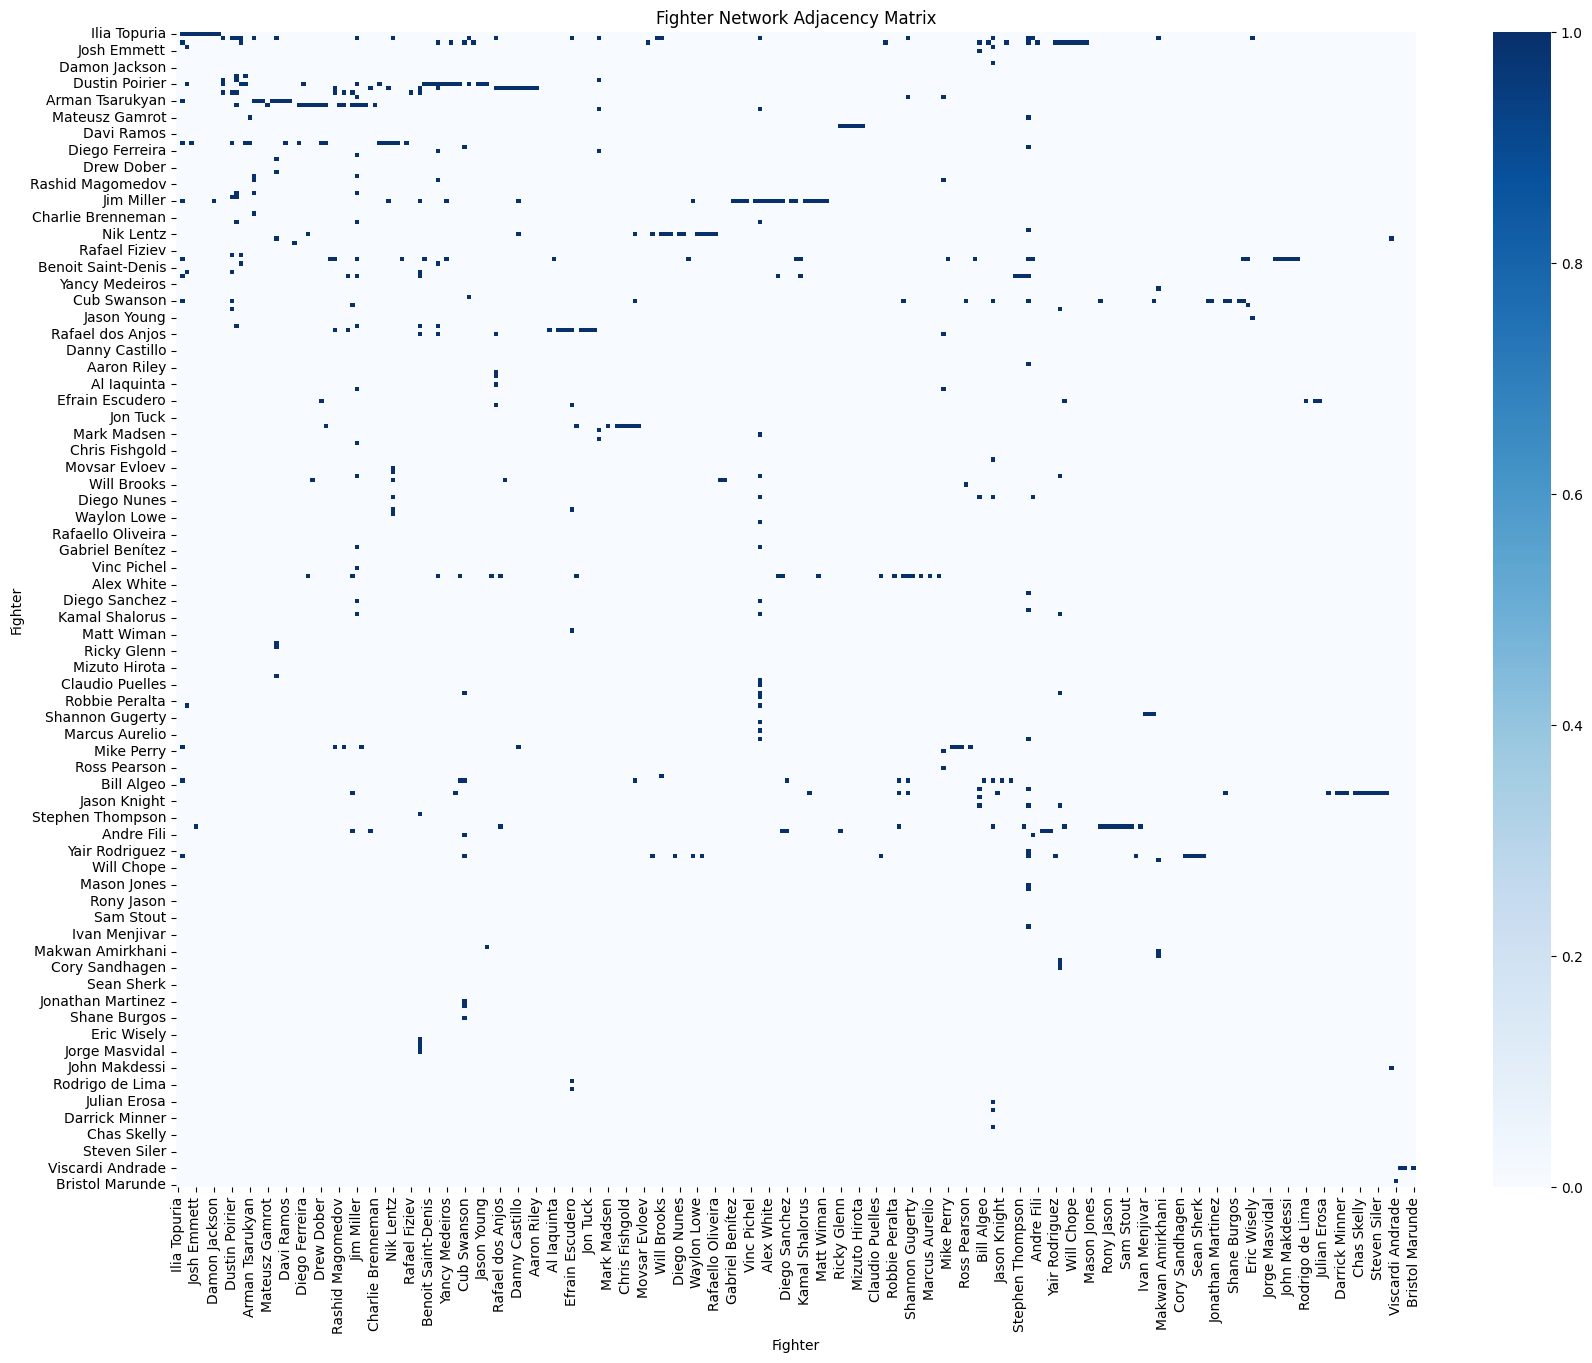

In [11]:
import seaborn as sns

adj_matrix = nx.to_pandas_adjacency(fighter_graph)

plt.figure(figsize=(20, 15))
sns.heatmap(adj_matrix, cmap="Blues")
plt.title("Fighter Network Adjacency Matrix")
plt.xlabel("Fighter")
plt.ylabel("Fighter")
plt.show()

The adjacency matrix is naturally sparse because most fighters rarely face the same opponent more than once, resulting in relatively few connections compared to all possible matchups in the network.

In [12]:
from pprint import pprint

largest_cc = max(nx.connected_components(fighter_graph.to_undirected()), key=len)
subgraph = fighter_graph.subgraph(largest_cc).to_undirected()

diameter = nx.diameter(subgraph)

periphery = nx.periphery(subgraph)
periphery_weight_classes = [subgraph.nodes[f]["weight_class"] for f in periphery if "weight_class" in subgraph.nodes[f]]
most_common_weight_class = Counter(periphery_weight_classes).most_common(1)

print(f"Diameter of the network: {diameter}")
print(30 * "-")
print(f"Fighters in the Periphery of the network: {len(periphery)}")
print(f"Most common weight class in periphery: {most_common_weight_class[0][0]} ({most_common_weight_class[0][1]} fighters)")
print("First 10:")
pprint(periphery[:10])

Diameter of the network: 5
------------------------------
Fighters in the Periphery of the network: 97
Most common weight class in periphery: Lightweight (44 fighters)
First 10:
['Bryce Mitchell',
 'Jai Herbert',
 'Ryan Hall',
 'Youssef Zalal',
 'Frank Camacho',
 'Rashid Magomedov',
 'Daron Cruickshank',
 'Anthony Rocco Martin',
 'Charlie Brenneman',
 'Rinat Fakhretdinov']


The diameter of the network is 5, meaning the longest shortest path between any two fighters in this connected subgraph is five bouts. In practical terms, it takes at most five consecutive wins or losses to connect even the most distant fighters in this part of the network.

The periphery of the network includes 97 fighters whose connections place them at this maximum distance from others. Interestingly, the most common weight class in the periphery is Lightweight, with 44 fighters — highlighting how deep and competitive this division is.

Some examples of fighters in the periphery include Bryce Mitchell, Ryan Hall, and Rinat Fakhretdinov. Their placement suggests they’re on the edge of this local fight network, often linked through just a handful of indirect matchups to the core cluster of more connected fighters.

### Round 3 — Touching Gloves: Clustering and Components

Now that we understand the basic shape of the fighter network, it’s time to touch gloves and look closer at how fighters naturally group together. In this round, we explore clustering, which tells us whether fighters tend to form tight circles.

We’ll start by looking at the local clustering coefficient for a few well-known fighters to see how connected their immediate “fight neighborhood” is. Then we’ll calculate the global clustering coefficient, which shows how likely it is that any two fighters connected to the same opponent have also faced each other.

In [13]:
# Local clustering coefficient for a few well-known fighters
well_known_fighters = ["Charles Oliveira", "Dustin Poirier", "Max Holloway"]
for fighter in well_known_fighters:
    if fighter in subgraph.nodes:
        coeff = nx.clustering(subgraph, fighter)
        print(f"Local clustering coefficient for {fighter}: {coeff:.3f}")
    else:
        print(f"{fighter} not found in the network.")

# Global clustering coefficient for the whole network
global_coeff = nx.transitivity(subgraph)
print(f"Global clustering coefficient (transitivity): {global_coeff:.3f}")

Local clustering coefficient for Charles Oliveira: 0.105
Local clustering coefficient for Dustin Poirier: 0.089
Local clustering coefficient for Max Holloway: 0.105
Global clustering coefficient (transitivity): 0.073


The local clustering coefficients for Charles Oliveira (0.105), Dustin Poirier (0.089), and Max Holloway (0.105) suggest that these top fighters’ immediate networks have a low but noticeable tendency to form small circles — meaning some of their opponents have also fought each other. This makes sense for high-profile fighters who often face the same pool of contenders in their divisions. Also, because the scraping was limited to a few levels of matchups, these local clusters only reflect a small slice of each fighter’s full career network.

The global clustering coefficient, or transitivity, is 0.073. This low value reflects the reality of MMA matchmaking: while rivalries and rematches happen, fighters typically face a diverse range of opponents rather than staying in tight, closed groups — keeping the overall network only loosely clustered.



Finally, we’ll break down the network into its strongly and weakly connected components. This helps us spot whether there are isolated clusters of fighters who don’t link back to the main graph, or if the network forms one large, loosely connected web when we ignore fight direction.

In [14]:
# Strongly connected components
strong_components = list(nx.strongly_connected_components(fighter_graph))
print(f"Number of strongly connected components: {len(strong_components)}")
print(f"Largest strongly connected component size: {max(len(c) for c in strong_components)}")

# Weakly connected components (ignoring fight direction)
weak_components = list(nx.weakly_connected_components(fighter_graph))
print(f"Number of weakly connected components: {len(weak_components)}")
print(f"Largest weakly connected component size: {max(len(c) for c in weak_components)}")

Number of strongly connected components: 201
Largest strongly connected component size: 77
Number of weakly connected components: 2
Largest weakly connected component size: 272


Finally, analyzing the connected components shows how the fight network holds together in practice. There are 201 strongly connected components, meaning there are many small pockets where fighters are linked by cycles of wins and losses — but the largest strongly connected component has only 77 fighters. In contrast, the network has just 2 weakly connected components, with the largest one containing 272 fighters. This confirms that when we ignore the direction of wins and losses, almost all fighters are part of one big interconnected fight scene, with only a tiny fraction remaining fully disconnected.

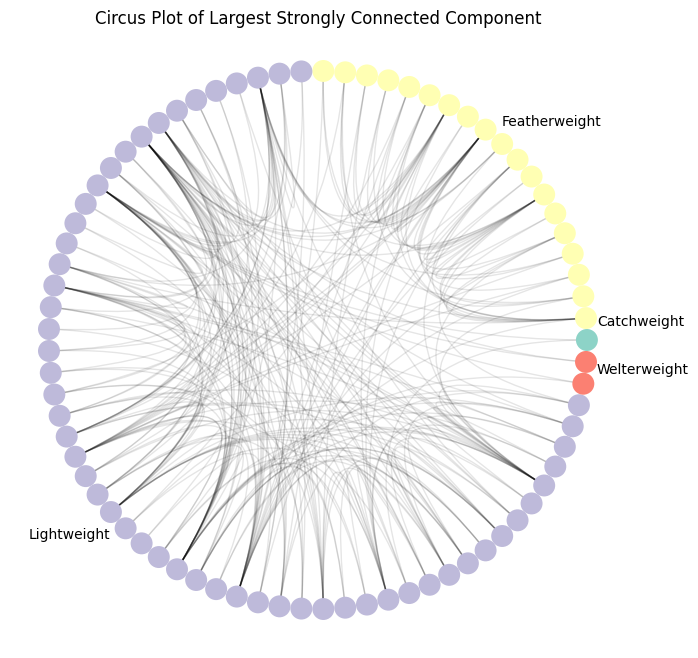

In [61]:
largest_scc = max(strong_components, key=len)
scc_subgraph = fighter_graph.subgraph(largest_scc)

plt.figure(figsize=(16, 8))
ax = nv.circos(scc_subgraph, node_color_by="weight_class", sort_by="weight_class")
annotate.circos_group(scc_subgraph, group_by="weight_class")

plt.title("Circus Plot of Largest Strongly Connected Component")
plt.show()


The circus plot above shows the structure of the largest strongly connected component in the network. Each node represents a fighter, arranged by weight class. We can see that most fighters belong to Lightweight and Featherweight, with a few in Welterweight and Catchweight.

The dense tangle of edges highlights how these fighters are all linked by cycles of wins and losses, forming a tight cluster where it’s possible to reach any fighter from any other through directed matchups. This visualization makes it clear how certain weight classes naturally produce closed loops of competition, reinforcing the small-world nature of the MMA ecosystem.

## Round 4 — The Title Fight: Who Really Matters?

With the network’s structure and clusters mapped out, it’s time for the title fight — figuring out who holds real influence inside this web of matchups. In this round, we’ll dive into node centrality to rank fighters by how important they are within the network.

Degree centrality shows which fighters have the most connections — the busiest careers.

In [34]:
# Calculate degree centrality for all fighters in the graph
degree_centrality = nx.degree_centrality(fighter_graph)

# Get the top 5 fighters by degree centrality
top_5 = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 fighters by degree centrality:")
for fighter, centrality in top_5:
    print(f"{fighter}: {centrality:.3f}")

Top 5 fighters by degree centrality:
Jim Miller: 0.159
Clay Guida: 0.134
Donald Cerrone: 0.127
Jeremy Stephens: 0.123
Charles Oliveira: 0.116


Closeness centrality reveals who sits at the center of the action, needing the fewest fights to reach anyone else.



In [35]:
# Calculate closeness centrality for all fighters in the graph
closeness_centrality = nx.closeness_centrality(fighter_graph)

# Get the top 5 fighters by closeness centrality
top_5_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 fighters by closeness centrality:")
for fighter, centrality in top_5_closeness:
    print(f"{fighter}: {centrality:.3f}")

Top 5 fighters by closeness centrality:
Clay Guida: 0.156
Jim Miller: 0.154
Jeremy Stephens: 0.153
Charles Oliveira: 0.150
Anthony Pettis: 0.145


Betweenness centrality highlights fighters who act as bridges between otherwise distant parts of the network.



In [36]:
# Calculate betweenness centrality for all fighters in the graph
betweenness_centrality = nx.betweenness_centrality(fighter_graph)

# Get the top 5 fighters by betweenness centrality
top_5_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 fighters by betweenness centrality:")
for fighter, centrality in top_5_betweenness:
    print(f"{fighter}: {centrality:.3f}")

Top 5 fighters by betweenness centrality:
Charles Oliveira: 0.101
Jim Miller: 0.066
Donald Cerrone: 0.060
Jeremy Stephens: 0.052
Clay Guida: 0.049


Eigenvector centrality rewards fighters who are connected to other influential fighters, surfacing hidden hubs of prestige.



In [37]:
# Calculate eigenvector centrality for all fighters in the graph
eigenvector_centrality = nx.eigenvector_centrality(fighter_graph, max_iter=1000)

# Get the top 5 fighters by eigenvector centrality
top_5_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 fighters by eigenvector centrality:")
for fighter, centrality in top_5_eigenvector:
    print(f"{fighter}: {centrality:.3f}")

Top 5 fighters by eigenvector centrality:
Jim Miller: 0.294
Jeremy Stephens: 0.271
Donald Cerrone: 0.217
Charles Oliveira: 0.213
Anthony Pettis: 0.207


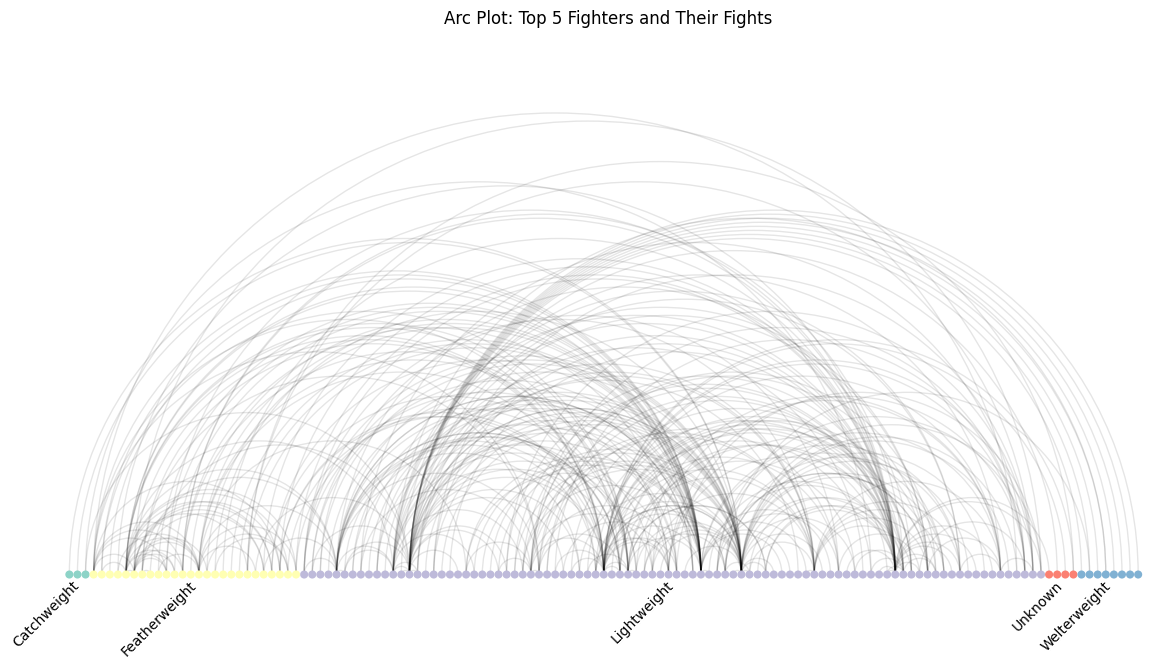

In [63]:
# Extract fighter names from top_5 tuples
top_5_names = [name for name, _ in top_5]

# Create a subgraph containing the top 5 fighters and their direct neighbors
top_5_nodes = set(top_5_names)
neighbors = set()
for fighter in top_5_names:
    neighbors.update(fighter_graph.successors(fighter))
    neighbors.update(fighter_graph.predecessors(fighter))
top_5_subgraph_nodes = top_5_nodes.union(neighbors)
top_5_subgraph = fighter_graph.subgraph(top_5_subgraph_nodes)

plt.figure(figsize=(14, 8))
ax = nv.arc(
    top_5_subgraph,
    node_color_by="weight_class",
    sort_by="weight_class",
)

annotate.arc_group(top_5_subgraph, group_by="weight_class")
plt.title("Arc Plot: Top 5 Fighters and Their Fights")
plt.show()


## Round 5 — The Post-Fight Press Conference: Finding Hidden Camps

As the final round, it’s time to step back and look at the bigger picture: how do fighters naturally group into communities within the network? Using the Louvain method for community detection, we can uncover clusters of fighters who are more densely connected to each other than to the rest of the network.

These communities can reflect hidden patterns like regional fight scenes, shared weight classes, training camps, or promotional matchups. By visualizing these clusters and comparing them to real-world factors, we get a clearer sense of how the MMA ecosystem organizes itself behind the scenes.

Detected communities: 11


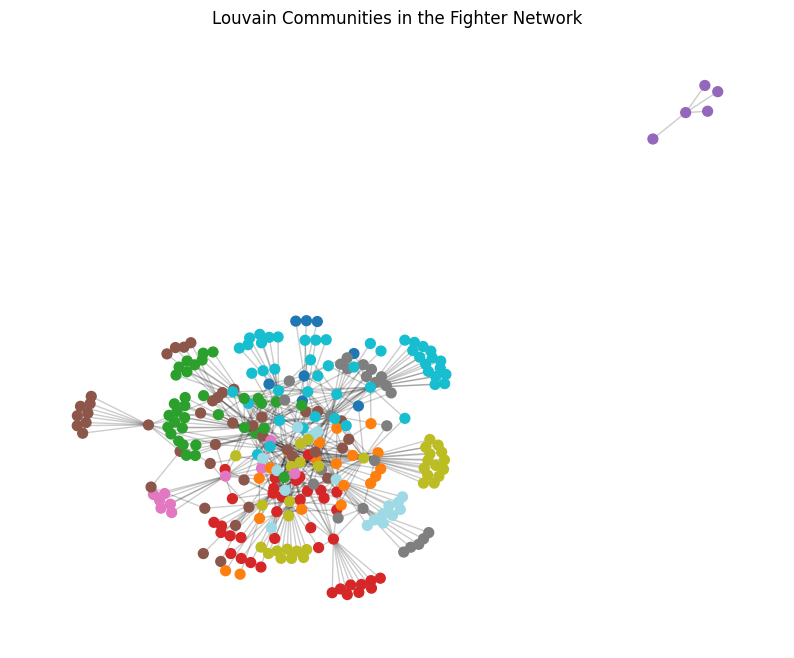

In [66]:
import networkx as nx
import community as community_louvain  # python-louvain package
import matplotlib.pyplot as plt

# Make sure your graph is undirected for Louvain
undirected = fighter_graph.to_undirected()

# Run Louvain method
partition = community_louvain.best_partition(undirected)

# Each node gets a community label
nx.set_node_attributes(undirected, partition, 'community')

# Example: count number of communities
num_communities = len(set(partition.values()))
print(f"Detected communities: {num_communities}")

# Optional: visualize with colors
pos = nx.spring_layout(undirected, seed=42)
colors = [partition[node] for node in undirected.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(undirected, pos, node_size=50, node_color=colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(undirected, pos, alpha=0.2)
plt.title("Louvain Communities in the Fighter Network")
plt.axis('off')
plt.show()

The visualization above shows how the Louvain algorithm groups fighters into distinct communities based on their patterns of matchups. Each color represents a different cluster — often shaped by factors like weight class, regional circuits, or training camps.

We can see a large, dense core where many fighters are tightly linked, along with smaller satellite communities and even a tiny isolated cluster in the top right. This highlights how the UFC’s matchmaking connects most fighters into a single competitive ecosystem, while still leaving room for local clusters and niche rivalries to emerge.

## Final Bell — Wrapping Up the Fight

From a single fighter profile to a full-fledged network of matchups, this analysis shows how the Tapology dataset can be transformed into a living map of the MMA world. By scraping and connecting fight results, we revealed how fighters cluster into weight classes and camps, how key contenders act as bridges, and how the network stays mostly connected despite its vast reach.

Whether looking at centrality to find hidden influencers, clustering to spot tight rivalries, or communities to uncover regional patterns, this project proves that behind every bout is a rich, structured network waiting to be explored. And just like the sport itself, it’s never static — it grows with every new fight.

The methods and visualizations here are just the start — new fighters, fresh rivalries, and deeper metrics can keep expanding this fight map long after the final bell rings.